<p align="center">
• <a href="https://mayzune.com/"><strong>May Zune</strong></a> •
<a href="https://github.com/hellomayzune"><strong>GitHub</strong></a> •
<a href="https://orcid.org/0000-0003-0282-2633"><strong>ORCID</strong></a> •
<a href="https://scholar.google.com/citations?user=LmP8B_4AAAAJ&hl=en"><strong>Google Scholar</strong></a> •
<a href="https://www.researchgate.net/profile/May-Zune"><strong>ResearchGate</strong></a> •
<a href="https://www.linkedin.com/in/mayzune//"><strong>Linkedin</strong></a> •
</p>

# Week 5 — Black-box Optimisation, Functions 1–8

- success: F2, F3, F4, F5
- fail: F1, F6, F7, F8

| # | Prediction / Optimisation Method | Hierarchical Feature Learning | Explore–Exploit Trade-off |
|---------|----------------------------------|-------------------------------|---------------------------|
| **F1*** | GP (Matérn ν = 2.5, length scale fixed at 0.15) on log-transformed \|outputs\|; acquisition = UCB (κ = 4.0) over 10,000 random candidates | **None.** Raw 2D inputs are used directly by the GP kernel. | **Explicit.** UCB balances exploitation and exploration through κ. Fixing the kernel length scale also stabilises exploration by preventing the GP optimiser from over-smoothing the surrogate, addressing a previously observed failure mode. |
| **F2** | Random Forest regression; greedy argmax of predicted mean over 50,000 random candidates | **None.** Raw features only; no feature engineering or learned representations. | **Predominantly exploitative.** Selection is based solely on the predicted mean. Exploration arises only indirectly from the breadth of the randomly generated candidate pool rather than the acquisition function. |
| **F3** | Random Forest trained on degree-2 polynomial features (A, B, C, A·B, A·C, B·C, A², B², C²); argmax over 10,000 global candidates | **Manual feature engineering.** PolynomialFeatures explicitly construct interaction and quadratic terms rather than learning representations automatically. | **Predominantly exploitative.** Candidate selection maximises predicted performance, while global candidate generation provides broad search coverage instead of relying on local optimisation. |
| **F4** | RF surrogate; uncertainty estimated from tree-to-tree disagreement (`rf_predict_with_std`); acquisition = EI (ξ = 0.01) over Latin Hypercube candidates | **None.** Raw inputs are used directly. RF partitions the feature space but does not learn hierarchical representations. | **Explicit and principled.** Expected Improvement balances predicted gain against ensemble uncertainty, while Latin Hypercube Sampling promotes uniform exploration of the design space. |
| **F5** | Two-stage approach: SVR pre-filters candidates (top 3,000 retained), then GP (log-transformed outputs, Matérn kernel) evaluates them using EI (ξ = 0.005) | **None.** Both SVR and GP operate directly on the original feature space. | **Exploration constrained by design.** Candidate generation focuses on local perturbations around the current best solution, making the search primarily exploitative. EI contributes a modest uncertainty-driven exploration component. |
| **F6** | RF surrogate; acquisition via Thompson sampling using a single randomly selected decision tree rather than the ensemble mean | **None.** Raw features only. | **Explicit stochastic exploration.** Randomly selecting one tree approximates Thompson sampling, naturally encouraging exploration because different trees disagree most in sparsely sampled regions. |
| **F7** | Two-stage approach: RBF interpolator (multiquadric kernel) scores the full candidate set, then RF re-ranks the top 1,000 candidates | **None.** Both models use the original feature space without learned representations. | **Explicit two-stage strategy.** The RBF model encourages exploration through extrapolation beyond observed values, while the RF stage exploits learned patterns by filtering implausible high-scoring candidates. |
| **F8** | MC-Dropout MLP (2 hidden layers, dropout active during inference with 50 stochastic forward passes); acquisition = UCB (κ = 3.0) | **Yes.** Hidden layers learn nonlinear, hierarchical representations of the input variables directly from data, unlike the hand-engineered or raw-feature approaches used in F1–F7. | **Explicit and model-native.** MC-dropout provides Bayesian-style predictive uncertainty from multiple stochastic forward passes, while UCB combines predictive mean and uncertainty to balance exploration and exploitation. |

In [1]:
# -----------------------------------------------------------------------------
# Imports
# -----------------------------------------------------------------------------

import warnings

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import RBFInterpolator
from scipy.spatial.distance import cdist
from scipy.stats import norm
from scipy.stats.qmc import LatinHypercube
from sklearn.ensemble import RandomForestRegressor
from sklearn.exceptions import ConvergenceWarning
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.svm import SVR

import pandas as pd
from pandas.plotting import parallel_coordinates

# -----------------------------------------------------------------------------
# Warning configuration
# -----------------------------------------------------------------------------

warnings.filterwarnings("ignore", category=ConvergenceWarning)

# Helper Functions

In [2]:
# Upper Confidence Bound acquisition: rewards both high predicted mean (mu)
# and high uncertainty (sigma); kappa controls the exploration/exploitation trade-off
def compute_ucb(mu, sigma, kappa=2.5):
    return mu + kappa * sigma

# Expected Improvement acquisition: expected gain over the current best (f_best),
# accounting for uncertainty; xi is a small exploration margin
def compute_ei(mu, sigma, f_best, xi=0.01):
    z = (mu - f_best - xi) / (sigma + 1e-9)
    ei = (mu - f_best - xi) * norm.cdf(z) + sigma * norm.pdf(z)
    ei[sigma == 0] = 0
    return ei

# Formats a candidate point as a clipped, hyphen-separated string ready to submit as a query
def format_query(point, decimals=6):
    point_clipped = np.clip(point, 0, 0.999999)
    return '-'.join([f'{x:.{decimals}f}' for x in point_clipped])

def plot_parallel_coordinates(candidates, scores, query, dim_labels, top_k=300, title=''):
    """Parallel-coordinates view of the top-k candidates by acquisition score,
    with the selected query overlaid as a thick red line."""
    top_idx = np.argsort(scores)[-top_k:]
    fig, ax = plt.subplots(figsize=(10, 5))
    norm = plt.Normalize(scores[top_idx].min(), scores[top_idx].max())
    cmap = plt.cm.viridis
    for idx in top_idx:
        ax.plot(range(len(dim_labels)), candidates[idx], color=cmap(norm(scores[idx])),
                alpha=0.25, linewidth=1)
    ax.plot(range(len(dim_labels)), query, color='red', linewidth=3,
            marker='*', markersize=14, label='Week 6 query', zorder=5)
    ax.set_xticks(range(len(dim_labels)))
    ax.set_xticklabels(dim_labels)
    ax.set_ylabel('Value (0–1 scale)')
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    fig.colorbar(sm, ax=ax, label='Acquisition score')
    ax.legend()
    ax.set_title(title)
    plt.tight_layout()
    plt.show()    

# Function 1, Radiation field, 2D array, 10 original samples - Week 5

In [3]:
# =============================================================================
# FUNCTION 1 - Radiation field, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Two-stage strategy: EI balances predicted improvement and uncertainty, 
#      while the distance criterion explicitly promotes spatial diversity, producing an EI + diversity hybrid.
# W4: GP (Matérn ν = 2.5) on log₁₀ outputs + UCB (κ = 5.0, exploration-heavy)

# change: Fixes the kernel length scale in a log-transformed GP UCB process to prevent over-smoothing and maintain stable 
#         aggressive exploration across the raw input space.

print("=" * 60)
print("Function 1 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append every query/output collected
f1_inputs  = np.load('initial_data/function_1/initial_inputs.npy')
f1_outputs = np.load('initial_data/function_1/initial_outputs.npy')

prev_queries_1 = np.array([
    [0.75, 0.75],
    [0.803076, 0.431805],
    [0.513943, 0.454749],
])
prev_outputs_1 = np.array([
    1.33E-22,
    2.04E-50,
    -3.89E-08,
])

all_inputs_F1  = np.vstack([f1_inputs, prev_queries_1])
all_outputs_F1 = np.hstack([f1_outputs, prev_outputs_1])

print(f"Total points: {len(all_outputs_F1)}")
print(f"Current best (max): {all_outputs_F1.max():.6e}")

Function 1 - Week 5
Total points: 13
Current best (max): 7.710875e-16


In [4]:
# Step 2: Fit the surrogate model.
# Outputs span many orders of magnitude, so we again work in log10(|output|) space. 
# This week the Matern length scale is fixed at 0.15 ("fixed" bounds, so the optimiser cannot change it) 
# rather than left free, to stop the GP from over-smoothing the surrogate — a failure mode observed previously.

abs_outputs_F1       = np.abs(all_outputs_F1)           
abs_outputs_floor_F1 = abs_outputs_F1 + 1e-300          
log_outputs_F1       = np.log10(abs_outputs_floor_F1)   

kernel = Matern(nu=2.5, length_scale=0.15, length_scale_bounds="fixed")
gp1     = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=10, normalize_y=True)
gp1.fit(all_inputs_F1, log_outputs_F1)

,kernel,"Matern(length...=0.15, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,10
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__length_scale,0.15
,kernel__length_scale_bounds,'fixed'
,kernel__nu,2.5


In [5]:
# Step 3: Generate candidates and select the next query.
# Draw 10,000 candidates uniformly at random over the full input space, 
# score each with UCB (kappa=4.0, balancing exploration/exploitation), and pick the best-scoring point. 
# Distance to existing samples is reported for reference only 
# (unlike Week 4, it is no longer used to mask out nearby candidates).

print("=" * 60)
print("Function 1 - Week 5")
print("=" * 60)

np.random.seed(42)
candidates_F1 = np.random.uniform(0, 1, (10000, 2))

mu_F1, sigma_F1 = gp1.predict(candidates_F1, return_std=True)
ucb_F1       = compute_ucb(mu_F1, sigma_F1, kappa=4.0)

best_idx_F1 = np.argmax(ucb_F1)
query_F1    = candidates_F1[best_idx_F1]

min_dist_F1 = cdist(candidates_F1, all_inputs_F1).min(axis=1)

print(f"\nWeek 5 Query: {format_query(query_F1)}")
print(f"mu: {mu_F1[best_idx_F1]:.4f}, sigma: {sigma_F1[best_idx_F1]:.4f}")
print(f"Min distance from existing samples: {min_dist_F1[best_idx_F1]:.4f}")

Function 1 - Week 5

Week 5 Query: 0.994654-0.996067
mu: -50.8396, sigma: 33.7064
Min distance from existing samples: 0.3393


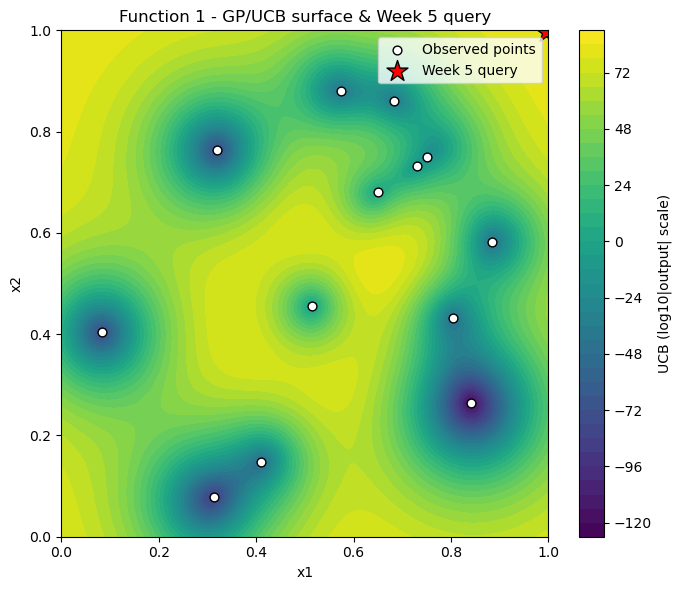

In [6]:
# Plot: GP posterior + UCB surface (Function 1's actual acquisition), 2D so a full contour is possible.
xx, yy = np.meshgrid(np.linspace(0, 1, 200), np.linspace(0, 1, 200))
grid_F1 = np.column_stack([xx.ravel(), yy.ravel()])

mu_grid_F1, sigma_grid_F1 = gp1.predict(grid_F1, return_std=True)
ucb_grid_F1 = compute_ucb(mu_grid_F1, sigma_grid_F1, kappa=4.0).reshape(xx.shape)

fig, ax = plt.subplots(figsize=(7, 6))
c = ax.contourf(xx, yy, ucb_grid_F1, levels=40, cmap='viridis')
plt.colorbar(c, label='UCB (log10|output| scale)')

ax.scatter(all_inputs_F1[:, 0], all_inputs_F1[:, 1],
           c='white', edgecolor='k', s=40, label='Observed points')
ax.scatter(*query_F1, c='red', marker='*', s=250, edgecolor='k', label='Week 5 query')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 1 - GP/UCB surface & Week 5 query')
ax.legend()
plt.tight_layout()
plt.show()

# Function 2, Noisy Log-Likelihood, 2D array, 10 original samples - Week 5

In [7]:
# =============================================================================
# FUNCTION 2 - Function 2, Noisy Log-Likelihood, 2D array, 10 original samples
# =============================================================================
# Previous weeks
# W3: Same GP + EI + distance-maximisation pipeline as F1.
# W4: GP (Matérn + WhiteKernel noise) + Thompson sampling

# change: Relying on a simple Random Forest argmax, 
#         this approach relies on a massive candidate pool to indirectly provide exploration while remaining heavily exploitative.

print("\n" + "=" * 60)
print("Function 2 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2-4 observations.
f2_inputs = np.load('initial_data/function_2/initial_inputs.npy')
f2_outputs = np.load('initial_data/function_2/initial_outputs.npy')

prev_queries_2 = np.array([
    [1.053349, 0.934354],
    [0.660188, 0.32993],
    [0.729589, 0.938148],
])
prev_outputs_2 = np.array([-0.040652, 0.468742, 0.487563])

all_inputs_F2  = np.vstack([f2_inputs, prev_queries_2])
all_outputs_F2 = np.hstack([f2_outputs, prev_outputs_2])

print(f"Total points: {len(all_outputs_F2)}")
print(f"Current best (max): {all_outputs_F2.max():.3f}")


Function 2 - Week 5
Total points: 13
Current best (max): 0.611


In [8]:
# Step 2: Fit the surrogate model.
# Switch this week from a GP to a shallow Random Forest (500 shallow trees, max_depth=3) 
# as the surrogate for the noisy output surface, since RF  averaging is 
# naturally robust to noise without needing an explicit noise kernel. 
# Feature importances are printed as a quick sanity check.

rf_F2 = RandomForestRegressor(n_estimators=500, max_depth=3, min_samples_leaf=2, random_state=42)
rf_F2.fit(all_inputs_F2, all_outputs_F2)
print(f"Feature importances: x1={rf_F2.feature_importances_[0]:.3f}, x2={rf_F2.feature_importances_[1]:.3f}")

Feature importances: x1=0.909, x2=0.091


In [9]:
# Step 3: Generate candidates and select the next query.
# Draw a large pool of 50,000 random candidates and simply take the argmax of the RF's predicted mean —
# a purely exploitative strategy this week, with exploration coming only from 
# the breadth of the random candidate pool rather than from an explicit acquisition function.

np.random.seed(42)
candidates_F2 = np.random.uniform(0, 1, (50000, 2))
preds_F2      = rf_F2.predict(candidates_F2)
query_F2      = candidates_F2[np.argmax(preds_F2)]

print(f"\nWeek 5 Query: {format_query(query_F2)}")
print(f"Predicted mean: {preds_F2.max():.3f}")


Week 5 Query: 0.685444-0.332456
Predicted mean: 0.480


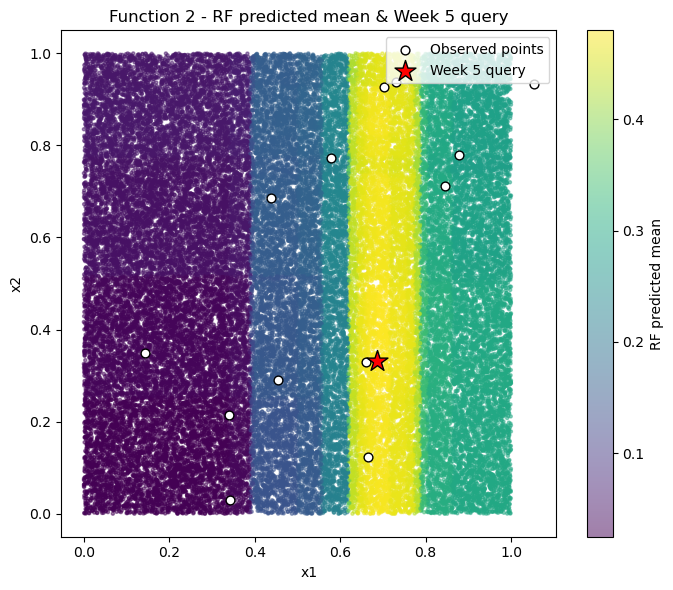

In [10]:
# Plot: RF-predicted mean over the candidate pool (Function 2's strategy is pure argmax,
# no explicit acquisition function - this shows exactly what "predicted mean" surface it maximised).
fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(candidates_F2[:, 0], candidates_F2[:, 1], c=preds_F2,
                 cmap='viridis', s=5, alpha=0.5)
plt.colorbar(sc, label='RF predicted mean')

ax.scatter(all_inputs_F2[:, 0], all_inputs_F2[:, 1],
           c='white', edgecolor='k', s=40, label='Observed points')
ax.scatter(*query_F2, c='red', marker='*', s=250, edgecolor='k', label='Week 5 query')

ax.set_xlabel('x1'); ax.set_ylabel('x2')
ax.set_title('Function 2 - RF predicted mean & Week 5 query')
ax.legend()
plt.tight_layout()
plt.show()

# Function 3, A drug discovery project, 3D array, 15 original samples - Week 5

In [11]:
# =============================================================================
# FUNCTION 3 - A drug discovery project, 3D array, 15 original samples
# =============================================================================
# Previous weeks
# W3: Explicitly mixes exploration (random candidates), local exploitation (perturbations near the best point), 
#     and hypothesis-driven exploitation (directed candidates).
# W4: GP EI (ξ = 0.001, exploitation-biased) blended 50/50 with quadratic polynomial surrogate

# change: Uses explicit polynomial feature engineering paired with global candidate sampling 
#         to exploit non-linear feature interactions while maintaining broad spatial coverage.

print("\n" + "=" * 60)
print("Function 3 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2-4 observations.
f3_inputs = np.load('initial_data/function_3/initial_inputs.npy')
f3_outputs = np.load('initial_data/function_3/initial_outputs.npy')

prev_queries_F3 = np.array([
    [0.540087, 0.652622, 0.079307],
    [0.378956, 0.302768, 0.459346],
    [0.375610, 0.057061, 0.589980],
])
prev_outputs_F3 = np.array([
    -0.050615,
    -0.019508,
    -0.119425,
])

X = np.vstack([f3_inputs, prev_queries_F3])
Y = np.hstack([f3_outputs, prev_outputs_F3])

print(f"Total points: {len(Y)}, best (max): {Y.max():.6f}")


Function 3 - Week 5
Total points: 18, best (max): -0.019508


In [12]:
# Step 2: Fit the surrogate model.
# As in previous weeks, degree-2 polynomial features (A, B, C and their interactions/squares) 
# are engineered by hand, but this week a Random Forest is trained on top of those features
# instead of a linear/GP model, then its feature importances are inspected to see which (engineered) terms matter most.
 
poly_F3   = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly_F3.fit_transform(X)

feature_names = ['A', 'B', 'C', 'A*B', 'A*C', 'B*C', 'A^2', 'B^2', 'C^2']

rf_F3 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_F3.fit(X_poly, Y)

print("\nRF feature importances:")
for name, imp in zip(feature_names, rf_F3.feature_importances_):
    print(f"  {name:6s}: {imp:.4f}")


RF feature importances:
  A     : 0.0502
  B     : 0.0379
  C     : 0.3386
  A*B   : 0.0644
  A*C   : 0.0460
  B*C   : 0.0435
  A^2   : 0.0243
  B^2   : 0.1223
  C^2   : 0.2727


In [13]:
# Step 3: Generate candidates and select the next query.
# Unlike Week 4's tight local search, candidates are now drawn uniformly across the whole 3D space (10,000 points), 
# transformed through the same polynomial feature map, scored by the RF, and 
# the best-predicted point is selected — global coverage this week rather than local refinement.

np.random.seed(42)
candidates_F3     = np.random.uniform(0, 1, (10000, 3))
cand_poly_F3      = poly_F3.transform(candidates_F3)
rf_preds_F3       = rf_F3.predict(cand_poly_F3)

best_idx_F3 = np.argmax(rf_preds_F3)
query_F3    = candidates_F3[best_idx_F3]

print(f"\nWeek 5 Query: {format_query(query_F3)}")
print(f"RF predicted mean: {rf_preds_F3[best_idx_F3]:.6f}")


Week 5 Query: 0.378956-0.302768-0.459346
RF predicted mean: -0.042114


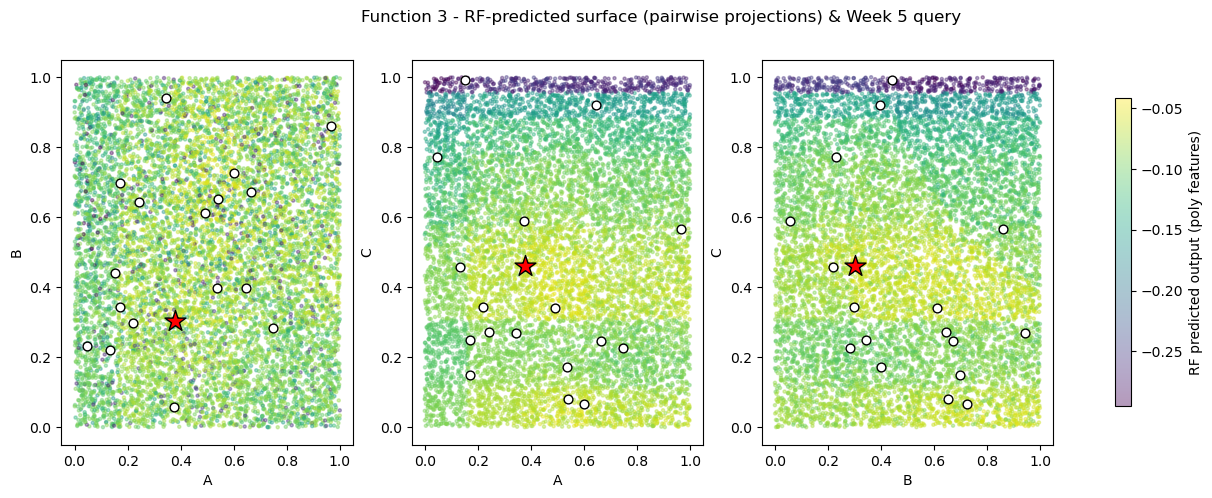

In [14]:
# Plot: RF-predicted score over the global candidate pool (Function 3's strategy),
# shown as three pairwise 2D projections since the search space is 3D.
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
pairs = [(0, 1, 'A', 'B'), (0, 2, 'A', 'C'), (1, 2, 'B', 'C')]

for ax, (i, j, name_i, name_j) in zip(axes, pairs):
    sc = ax.scatter(candidates_F3[:, i], candidates_F3[:, j], c=rf_preds_F3,
                     cmap='viridis', s=5, alpha=0.4)
    ax.scatter(X[:, i], X[:, j], c='white', edgecolor='k', s=40)
    ax.scatter(query_F3[i], query_F3[j], c='red', marker='*', s=250, edgecolor='k')
    ax.set_xlabel(name_i); ax.set_ylabel(name_j)

fig.colorbar(sc, ax=axes, label='RF predicted output (poly features)', shrink=0.8)
fig.suptitle('Function 3 - RF-predicted surface (pairwise projections) & Week 5 query')
plt.show()

# Function 4, Warehouse business, 4D array, 30 original samples - Week 5

In [15]:
# =============================================================================
# FUNCTION 4 - Warehouse business, 4D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Exploration-oriented due to relatively high (UCB, κ = 2.0) over 10k uniformly random candidates.
# W4: GP (Matérn) + Thompson sampling

# change: Leverages tree-to-tree variance within a RF to compute EI over LHS, 
#         achieving principled, uncertainty-driven exploration.

print("\n" + "=" * 60)
print("Function 4 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2-4 observations.
f4_inputs  = np.load('initial_data/function_4/initial_inputs.npy')
f4_outputs = np.load('initial_data/function_4/initial_outputs.npy')

prev_queries_F4 = np.array([
    [0.149845, 0.155724, 0.461280, 0.344491],
    [0.330258, 0.414348, 0.433728, 0.411341],
    [0.424125, 0.404716, 0.487507, 0.367688],
])
prev_outputs_F4 = np.array([-7.13212, 0.20379, -0.99160])

all_inputs_F4  = np.vstack([f4_inputs, prev_queries_F4])
all_outputs_F4 = np.hstack([f4_outputs, prev_outputs_F4])

print(f"Total points: {len(all_outputs_F4)}, best (max): {all_outputs_F4.max():.4f}")



Function 4 - Week 5
Total points: 33, best (max): 0.2038


In [16]:
# Step 2: Fit the surrogate model.
# A Random Forest is fit on the raw 4D inputs, then evaluated with 5-fold  cross-validated R^2 
# to sanity-check how well it generalises before it is used for candidate scoring below.

rf_F4 = RandomForestRegressor(n_estimators=500, min_samples_leaf=2,
                              max_features='sqrt', random_state=42)
rf_F4.fit(all_inputs_F4, all_outputs_F4)

kfold = KFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_F4, all_inputs_F4, all_outputs_F4, cv=kfold, scoring='r2')
print(f"CV: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
print(f"Feature importances: {rf_F4.feature_importances_.round(4)}")

CV: 0.5531 (+/- 0.1158)
Feature importances: [0.2959 0.3296 0.1205 0.254 ]


In [17]:
# Step 3: Generate candidates and select the next query.
# Since a plain RF doesn't expose predictive uncertainty, 
# a small helper is defined to derive mean and std from the spread of individual tree predictions 
# (tree-to-tree disagreement as a proxy for uncertainty). 
# This feeds an Expected Improvement acquisition (xi=0.01) evaluated over
#  a Latin Hypercube candidate set, and the top-scoring candidate is selected.

def rf_predict_with_std(rf_F4, X):
    tree_preds = np.array([t.predict(X) for t in rf_F4.estimators_])
    return tree_preds.mean(axis=0), tree_preds.std(axis=0)

candidates_F4 = LatinHypercube(d=4, seed=42).random(n=20000)

mu_F4, sigma_F4 = rf_predict_with_std(rf_F4, candidates_F4)
best_y_F4    = all_outputs_F4.max()
z_F4  = (mu_F4 - best_y_F4 - 0.01) / (sigma_F4 + 1e-9)
ei_F4 = (mu_F4 - best_y_F4 - 0.01) * norm.cdf(z_F4) + sigma_F4 * norm.pdf(z_F4)

query_F4 = candidates_F4[np.argmax(ei_F4)]

mu_q, sigma_q = rf_predict_with_std(rf_F4, query_F4.reshape(1, -1))

print(f"\nWeek 5 Query: {format_query(query_F4)}")
print(f"Predicted mean: {mu_q[0]:.4f}, std: {sigma_q[0]:.4f}")


Week 5 Query: 0.424125-0.404716-0.487507-0.367688
Predicted mean: -5.4498, std: 5.1767


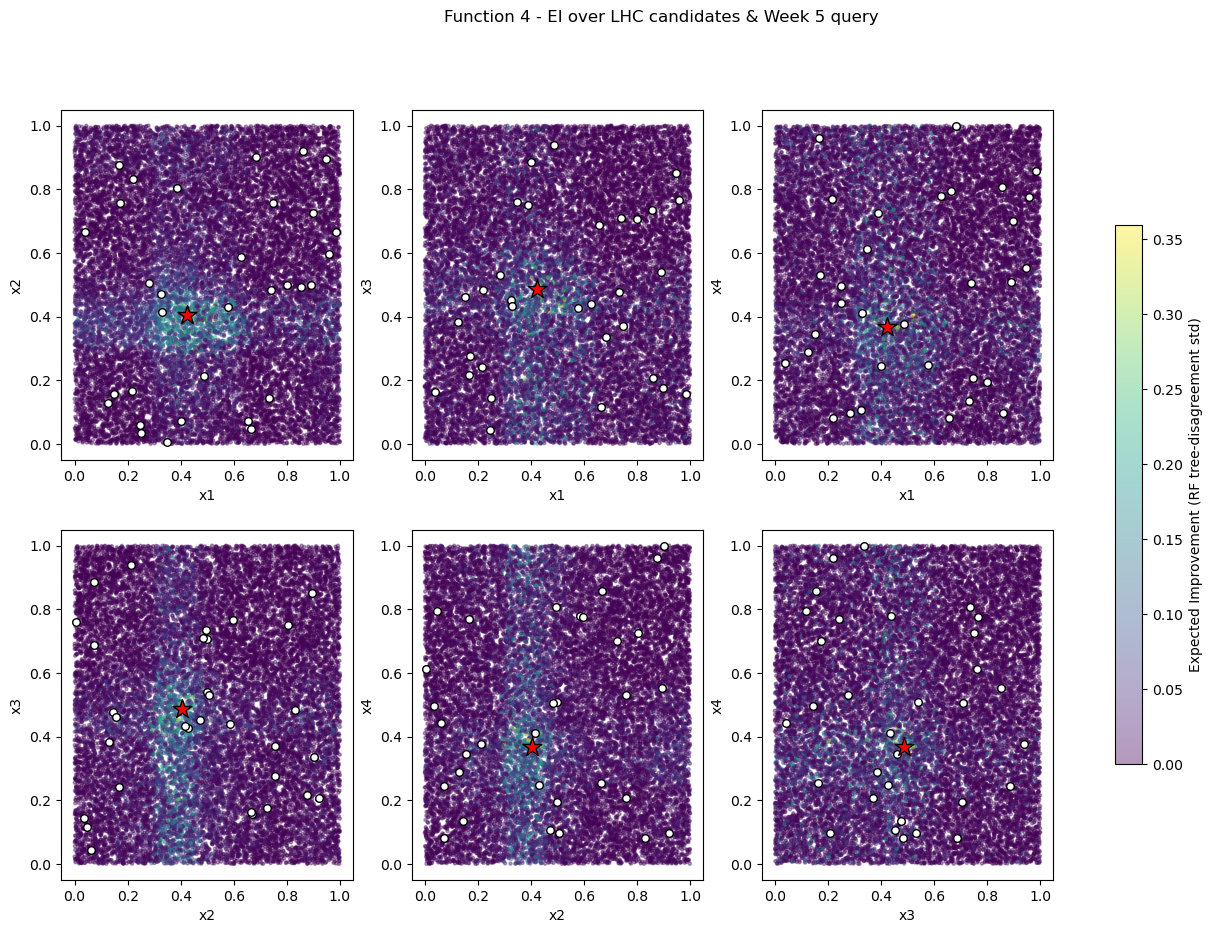

In [18]:
# Plot: Expected Improvement over the Latin-Hypercube candidate pool (Function 4's acquisition),
# shown as pairwise 2D projections across all 6 dimension-pairs of the 4D space.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
dims = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
labels = ['x1', 'x2', 'x3', 'x4']

for ax, (i, j) in zip(axes.ravel(), dims):
    sc = ax.scatter(candidates_F4[:, i], candidates_F4[:, j], c=ei_F4,
                     cmap='viridis', s=5, alpha=0.4)
    ax.scatter(all_inputs_F4[:, i], all_inputs_F4[:, j], c='white', edgecolor='k', s=30)
    ax.scatter(query_F4[i], query_F4[j], c='red', marker='*', s=200, edgecolor='k')
    ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])

fig.colorbar(sc, ax=axes, label='Expected Improvement (RF tree-disagreement std)', shrink=0.7)
fig.suptitle('Function 4 - EI over LHC candidates & Week 5 query')
plt.show()

# Function 5, A chemical process in a factory, 4D array, 20 original samples - Week 5

In [19]:
# =============================================================================
# FUNCTION 5 - Chemical Yield (4D)
# =============================================================================
# Previous weeks
# W3: Strong exploitation
#     SVR ranks a locally generated candidate pool (local perturbations and directional moves around the incumbent). 
# W4: Linear regression (search direction) → SVR pre-filter → GP EI (ξ = 0.005)

# change: Combines an SVR pre-filter with a GP EI evaluator to tightly constrain exploration and 
#         aggressively exploit local perturbations around the incumbent best point.

print("\n" + "=" * 60)
print("Function 5 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2-4 observations.
f5_inputs  = np.load('initial_data/function_5/initial_inputs.npy')
f5_outputs = np.load('initial_data/function_5/initial_outputs.npy')

prev_queries_F5 = np.array([
    [0.417098, 0.756030, 0.129487, 1.149173], 
    [0.386633, 0.821843, 0.127990, 0.999900],  
    [0.269378, 0.810637, 0.999999, 0.999999],  
])
prev_outputs_F5 = np.array([1829.809875, 710.602251, 2699.104490])

all_inputs_F5  = np.vstack([f5_inputs, prev_queries_F5])
all_outputs_F5 = np.hstack([f5_outputs, prev_outputs_F5])

print(f"Total points: {len(all_outputs_F5)}, best (max): {all_outputs_F5.max():.2f}")


Function 5 - Week 5
Total points: 23, best (max): 2699.10


In [20]:
# Step 2: Fit the surrogate models.
# Two models are trained on the full dataset, both carried over unchanged from Week 4: 
# an SVR (on standardised inputs/outputs) that will act as a cheap pre-filter, 
# and a GP (Matern kernel) fit on log1p-transformed outputs this week for a better-behaved surrogate surface.

input_scaler  = StandardScaler()
output_scaler = StandardScaler()
X_scaled = input_scaler.fit_transform(all_inputs_F5)
Y_scaled = output_scaler.fit_transform(all_outputs_F5.reshape(-1, 1)).ravel()

svr_F5 = SVR(kernel='rbf', C=100, gamma='scale', epsilon=0.1)
svr_F5.fit(X_scaled, Y_scaled)

y_log     = np.log1p(all_outputs_F5)
kernel_gp = ConstantKernel(1.0, (0.001, 1000)) * Matern(length_scale=0.2, nu=2.5)
gp_F5     = GaussianProcessRegressor(kernel=kernel_gp, n_restarts_optimizer=25, normalize_y=True)
gp_F5.fit(all_inputs_F5, y_log)

,kernel,"1**2 * Matern...e=0.2, nu=2.5)"
,alpha,1e-10
,optimizer,'fmin_l_bfgs_b'
,n_restarts_optimizer,25
,normalize_y,True
,copy_X_train,True
,n_targets,None
,random_state,None
,kernel__k1,1**2
,kernel__k2,"Matern(length...e=0.2, nu=2.5)"
,kernel__k1__constant_value,1.0


In [21]:
# Step 3: Generate candidates and select the next query.
# Build a candidate pool around the current best point — a "local" jittered  cluster and
# a "directed" cluster that nudges each dimension the same way as Week 4 (x3 pinned near its upper bound in both) —
# then use the SVR to cheaply pre-filter the pool down to the top 3,000 candidates, 
# and finally  score that shortlist with the GP's Expected Improvement 
# (on the log1p scale, xi=0.005) to pick the final query.

best_point = all_inputs_F5[np.argmax(all_outputs_F5)]
np.random.seed(42)

# local: small perturbations around w4 best (unchanged from w4)
local = []
for _ in range(6000):
    c    = best_point + np.random.normal(0, 0.03, 4)
    c    = np.clip(c, 0, 1)
    c[2] = 0.999999  # x3 pinned
    local.append(c)

directed = []
for _ in range(4000):
    c    = best_point.copy()
    c[0] = np.clip(c[0] - abs(np.random.normal(0, 0.05)), 0, 1)
    c[1] = np.clip(c[1] + abs(np.random.normal(0, 0.03)), 0, 1)
    c[2] = 0.999999
    c[3] = np.clip(c[3] + abs(np.random.normal(0, 0.03)), 0, 1)
    directed.append(c)

candidates_F5 = np.vstack([local, directed])

X_cand_scaled = input_scaler.transform(candidates_F5)
svr_preds_s   = svr_F5.predict(X_cand_scaled)
svr_preds     = output_scaler.inverse_transform(svr_preds_s.reshape(-1, 1)).ravel()

top_idx  = np.argsort(svr_preds)[-3000:]
filtered = candidates_F5[top_idx]

mu_log, sigma_log = gp_F5.predict(filtered, return_std=True)
ei                = compute_ei(mu_log, sigma_log, np.log1p(all_outputs_F5.max()), xi=0.005)

best_idx = np.argmax(ei)
query    = filtered[best_idx]

print(f"\nWeek 5 Query: {format_query(query)}")
print(f"GP predicted yield: {np.expm1(mu_log[best_idx]):.2f}")
print(f"GP std (log scale): {sigma_log[best_idx]:.4f}")
print(f"SVR prediction: {svr_preds[top_idx[best_idx]]:.2f}")
print(f"EI: {ei[best_idx]:.6f}")


Week 5 Query: 0.366671-0.879874-0.999999-0.996809
GP predicted yield: 2527.06
GP std (log scale): 0.5916
SVR prediction: 2618.43
EI: 0.202276


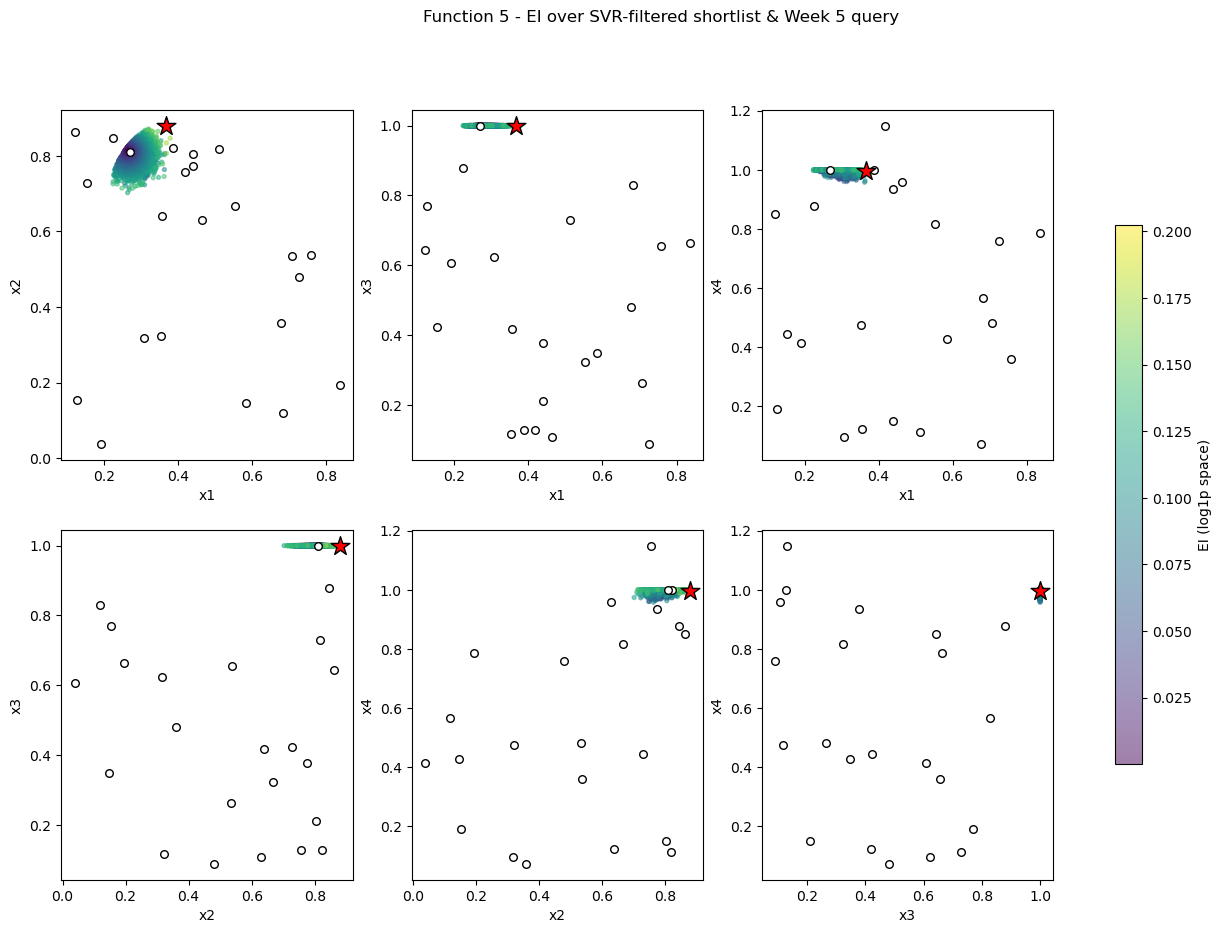

In [22]:
# Plot: Expected Improvement over the SVR-filtered shortlist (Function 5's second stage),
# shown as pairwise 2D projections. Only the top-3000-by-SVR candidates are shown,
# since those are the only ones the GP/EI stage actually evaluated.
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
dims = [(0, 1), (0, 2), (0, 3), (1, 2), (1, 3), (2, 3)]
labels = ['x1', 'x2', 'x3', 'x4']

for ax, (i, j) in zip(axes.ravel(), dims):
    sc = ax.scatter(filtered[:, i], filtered[:, j], c=ei,
                     cmap='viridis', s=8, alpha=0.5)
    ax.scatter(all_inputs_F5[:, i], all_inputs_F5[:, j], c='white', edgecolor='k', s=30)
    ax.scatter(query[i], query[j], c='red', marker='*', s=200, edgecolor='k')
    ax.set_xlabel(labels[i]); ax.set_ylabel(labels[j])

fig.colorbar(sc, ax=axes, label='EI (log1p space)', shrink=0.7)
fig.suptitle('Function 5 - EI over SVR-filtered shortlist & Week 5 query')
plt.show()

# Function 6 A cake recipe, 5D array, 20 original samples - Week 5

In [23]:
# =============================================================================
# FUNCTION 6 - A cake recipe, 5D array, 20 original samples
# =============================================================================
# Previous weeks
# W3: ARD GP + EI (ξ = 0.05) over a mixed candidate pool consisting of uniform random samples, 
#     Latin Hypercube Sampling (LHS), and perturbations around the top five recipes.
# W4: GP with ARD Matérn + EI (ξ = 0.02)

# change: Approximates Thompson sampling by evaluating single decision trees within an ensemble, 
#         using model disagreement to naturally drive exploration toward under-sampled regions.

print("\n" + "=" * 60)
print("Function 6 - Week 5")
print("=" * 60)

# Step 1: Load the original samples and append the Week 2-4 observations.
f6_inputs  = np.load('initial_data/function_6/initial_inputs.npy')
f6_outputs = np.load('initial_data/function_6/initial_outputs.npy')

prev_queries_F6 = np.array([
    [0.939456, 0.643603, 0.531941, 1.031640, 0.012391],
    [0.463219, 0.306404, 0.635240, 0.999844, 0.015672],
    [0.344063, 0.007363, 0.627449, 0.999999, 0.004891],
])
prev_outputs_F6 = np.array([-1.241946, -0.352945, -0.837300])

all_inputs_F6  = np.vstack([f6_inputs, prev_queries_F6])
all_outputs_F6 = np.hstack([f6_outputs, prev_outputs_F6])

print(f"Total observations: {all_inputs_F6.shape[0]}, best (max): {all_outputs_F6.max():.4f}")


Function 6 - Week 5
Total observations: 23, best (max): -0.3529


In [24]:
# Step 2: Fit the surrogate model.
# A standard Random Forest is fit on the raw 5D inputs 
# (replacing the ARD GP used in Week 4), and its feature importances are printed for reference.

rf_F6 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_F6.fit(all_inputs_F6, all_outputs_F6)

print("\nRandom Forest feature importances:")
for i, importance in enumerate(rf_F6.feature_importances_):
    print(f"  x{i+1}: {importance:.4f}")


Random Forest feature importances:
  x1: 0.0862
  x2: 0.1267
  x3: 0.0567
  x4: 0.2903
  x5: 0.4400


In [25]:
# Step 3: Generate candidates and select the next query.
# Draw candidates uniformly over the full 5D space, then 
# approximate Thompson sampling by picking one random tree from the forest 
# (instead of using the ensemble mean) and taking its argmax — 
# different trees disagree most in sparsely sampled regions, which naturally encourages exploration.

np.random.seed(42)
candidates_F6 = np.random.uniform(0, 1, (15000, 5))

np.random.seed(42)
random_tree_F6    = rf_F6.estimators_[np.random.randint(0, len(rf_F6.estimators_))]
tree_predicted_F6 = random_tree_F6.predict(candidates_F6)
best_index_F6     = np.argmax(tree_predicted_F6)
query_F6         = candidates_F6[best_index_F6]

print(f"\nWeek 5 Query: {format_query(query_F6)}")
print(f"Tree predicted mean: {tree_predicted_F6[best_index_F6]:.4f}")


Week 5 Query: 0.611853-0.139494-0.292145-0.366362-0.456070
Tree predicted mean: -0.7143


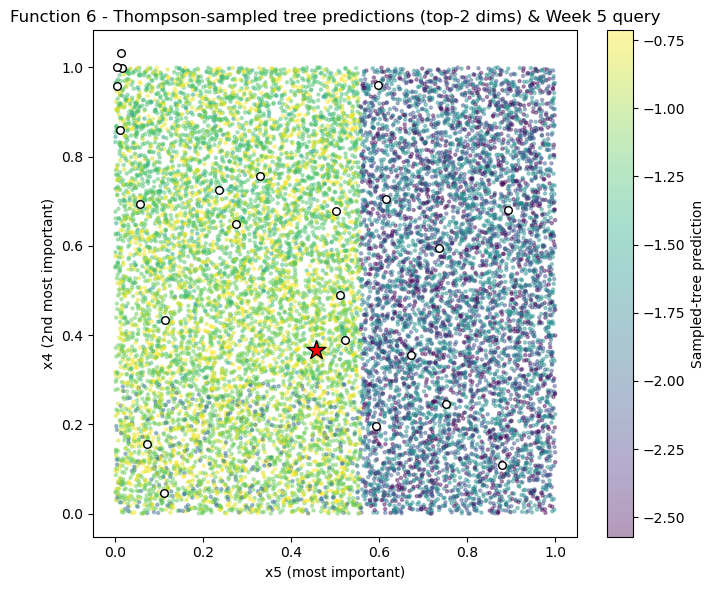

In [26]:
# Plot: the single randomly-picked tree's predictions (Function 6's Thompson-sampling acquisition),
# sliced on the two most important dimensions since a full 5D view isn't practical.
top2_F6 = np.argsort(rf_F6.feature_importances_)[::-1][:2]
i, j = top2_F6

fig, ax = plt.subplots(figsize=(7, 6))
sc = ax.scatter(candidates_F6[:, i], candidates_F6[:, j], c=tree_predicted_F6,
                 cmap='viridis', s=5, alpha=0.4)
ax.scatter(all_inputs_F6[:, i], all_inputs_F6[:, j], c='white', edgecolor='k', s=30)
ax.scatter(query_F6[i], query_F6[j], c='red', marker='*', s=200, edgecolor='k')
plt.colorbar(sc, label='Sampled-tree prediction')
ax.set_xlabel(f'x{i+1} (most important)'); ax.set_ylabel(f'x{j+1} (2nd most important)')
ax.set_title('Function 6 - Thompson-sampled tree predictions (top-2 dims) & Week 5 query')
plt.tight_layout()
plt.show()

# Function 7, Unspecified field, 6D array, 30 original samples - Week 5

In [27]:
# =============================================================================
# FUNCTION 7 - Unspecified field, 6D array, 30 original samples
# =============================================================================
# Previous weeks
# W3: Strong exploitation vis Random Forest + SHAP identifies influential variables and preferred directions
# W4: GP EI (on log1p outputs, ξ = 0.01) + MLP regressor (50/50 blend)

# change: Pairs an extrapolating RBF interpolator with a filtering Random Forest 
#         to explore unobserved spaces while pruning unrealistic candidate predictions.

print("\n" + "=" * 60)
print("Function 7 - Week 5")
print("=" * 60)
# Step 1: Load the original samples and append the Week 2-4 observations.
f7_inputs  = np.load('initial_data/function_7/initial_inputs.npy')
f7_outputs = np.load('initial_data/function_7/initial_outputs.npy')

prev_queries_F7 = np.array([
    [0.079933, 0.633654, 0.734486, 0.864915, 0.103811, 0.933346],  # w2
    [0.020000, 0.229276, 0.478532, 0.247457, 0.365999, 0.737383],  # w3
    [0.012357, 0.162903	, 0.399853, 0.082758, 0.249752, 0.923732],  # w4
])
prev_outputs_F7 = np.array([0.59279, 2.59480, 1.08804])

all_inputs_F7  = np.vstack([f7_inputs, prev_queries_F7])
all_outputs_F7 = np.hstack([f7_outputs, prev_outputs_F7])
log_outputs_F7 = np.log1p(all_outputs_F7)

print(f"Total points: {len(all_outputs_F7)}, best (max): {all_outputs_F7.max():.4f}")


Function 7 - Week 5
Total points: 33, best (max): 2.5948


In [28]:
# Step 2: Fit the surrogate models.
# Two complementary models are fit on log1p-transformed outputs: 
# a Random Forest (feature importances printed for reference) 
# that will re-rank the most promising candidates later, and an RBF interpolator 
# (multiquadric kernel) that will provide a cheap, 
# extrapolation-friendly first-pass score over a large candidate pool.

rf_F7 = RandomForestRegressor(n_estimators=200, random_state=42)
rf_F7.fit(all_inputs_F7, log_outputs_F7)

feature_names_F7 = [f"HP{i+1}" for i in range(6)]
print("\nRF feature importance:")
for name, imp in zip(feature_names_F7, rf_F7.feature_importances_):
    print(f"  {name}: {imp:.3f}")

rbf = RBFInterpolator(all_inputs_F7, log_outputs_F7, kernel='multiquadric', epsilon=1.0)


RF feature importance:
  HP1: 0.538
  HP2: 0.083
  HP3: 0.057
  HP4: 0.032
  HP5: 0.145
  HP6: 0.145


In [29]:
# Step 3: Generate candidates and select the next query.
# Draw a large pool of 50,000 random candidates and 
# score all of them cheaply with the RBF interpolator; 
# keep only the top 1,000 by RBF score, then re-rank that shortlist with 
# the (more expensive, more trustworthy) RF model and take its argmax as the final query. 
# The RBF stage favours exploration through extrapolation, 
# while the RF stage filters out implausible high-scoring candidates.

np.random.seed(42)
n          = 50000
candidates_F7 = np.random.uniform(0, 1, (n, 6))

rbf_preds  = rbf(candidates_F7)


top_n      = 1000
top_rbf    = np.argsort(rbf_preds)[-top_n:]
rf_preds   = rf_F7.predict(candidates_F7[top_rbf])


best_idx_F7   = top_rbf[np.argmax(rf_preds)]
query_F7     = candidates_F7[best_idx_F7]

print(f"\nWeek 5 Query: {format_query(query_F7)}")
print(f"RBF prediction (original): {np.expm1(rbf_preds[best_idx_F7]):.4f}")
print(f"RF  prediction (original): {np.expm1(rf_preds[np.argmax(rf_preds)]):.4f}")


Week 5 Query: 0.042283-0.348468-0.793617-0.259525-0.456849-0.822122
RBF prediction (original): 1.9435
RF  prediction (original): 1.7869


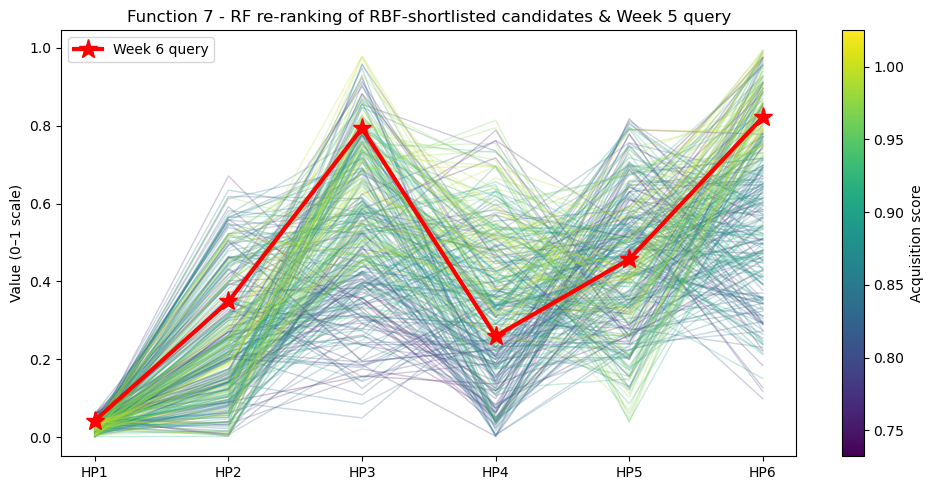

In [30]:
# Plot: parallel coordinates over the RBF-shortlisted, RF-reranked candidates (Function 7's
# two-stage strategy) - a 6D space is too crowded for pairwise scatter grids to stay readable.
plot_parallel_coordinates(
    candidates_F7[top_rbf], rf_preds, query_F7,
    dim_labels=[f'HP{i+1}' for i in range(6)],
    title='Function 7 - RF re-ranking of RBF-shortlisted candidates & Week 5 query'
)

# Function 8, Unspecified field, 8D array, 40 original samples - Week 5

In [31]:
# =============================================================================
# FUNCTION 8 - Unspecified field, 8D array, 40 original samples
# =============================================================================
# Previous weeks
# W3: Pipeline (a) combines partial exploration (free dimensions) with strong exploitation (pinned dimensions); 
#     Pipeline (b) is almost entirely exploitation-focused.
# W4: GP (ARD Matérn) UCB (κ = 2.0) + MLP regressor (50/50 blend)

# change: Utilises MC-Dropout in a deep neural network to learn complex hierarchical representations and 
#         derive explicit Bayesian-style uncertainty for balanced UCB optimisation.

print("\n" + "=" * 60)
print("Function 8 - Week 5")
print("=" * 60)

import torch
import torch.nn as nn
# This function switches to a neural-network surrogate, so PyTorch is imported here as well.

# Step 1: Load the original samples and append the Week 2-4 observations.
f8_inputs  = np.load('initial_data/function_8/initial_inputs.npy')
f8_outputs = np.load('initial_data/function_8/initial_outputs.npy')

prev_queries_F8 = np.array([
    [0.034736, 0.033935, 0.577646, 0.735810, 0.807192, 0.026536, 0.72178, 0.629862],
    [0.019981, 0.000000, 0.999999, 0.000000, 0.448273, 0.855526, 0.446219, 0.931836],
    [0.035148, 0.000000, 0.018976, 0.000000, 0.999999, 0.361194, 0.007310, 0.000000],
])
prev_outputs_F8 = np.array([8.26488, 7.35099, 9.76008])

all_inputs_F8  = np.vstack([f8_inputs, prev_queries_F8])
all_outputs_F8 = np.hstack([f8_outputs, prev_outputs_F8])

print(f"Total points: {len(all_outputs_F8)}, best: {all_outputs_F8.max():.4f}")


Function 8 - Week 5
Total points: 43, best: 9.7601


In [32]:
# Step 2: Prepare the data for the neural network.
# Standardise both inputs and outputs 
# (neural nets train much better on zero-mean/unit-variance data) and 
# convert everything to PyTorch tensors.

# scale inputs and outputs
scaler_x = StandardScaler()
scaler_y = StandardScaler()
X_sc = scaler_x.fit_transform(all_inputs_F8)
Y_sc = scaler_y.fit_transform(all_outputs_F8.reshape(-1, 1)).ravel()

X_tensor = torch.tensor(X_sc, dtype=torch.float32)
Y_tensor = torch.tensor(Y_sc, dtype=torch.float32).unsqueeze(1)

In [33]:
# Step 3: Define and train the surrogate model.
# A small 2-hidden-layer MLP with Dropout after each hidden layer is defined; crucially,
# dropout will be kept ACTIVE at inference time later (MC-Dropout)  to turn repeated stochastic forward passes
# into an approximate predictive uncertainty estimate. 
# The model is then trained for 1000 epochs with Adam to minimise MSE against the standardised outputs.

class DropoutMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim, dropout_rate):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(hidden_dim, 1)
        )
    def forward(self, x):
        return self.net(x)

torch.manual_seed(42)
model     = DropoutMLP(input_dim=8, hidden_dim=32, dropout_rate=0.1)
optimiser = torch.optim.Adam(model.parameters(), lr=1e-3)
loss_fn   = nn.MSELoss()

# train
model.train()
for epoch in range(1000):
    optimiser.zero_grad()
    pred = model(X_tensor)
    loss = loss_fn(pred, Y_tensor)
    loss.backward()
    optimiser.step()

print(f"Training loss (final): {loss.item():.4f}")

Training loss (final): 0.0245


In [34]:
# Step 4: Generate candidates, run MC-Dropout inference, and select the next query.
# mc_predict keeps the model in train() mode (so dropout stays active) and
# runs 50 stochastic forward passes over the candidates; 
# the mean and std across those passes give a Bayesian-style predictive mean/uncertainty.
# These are unscaled back to the original output units, 
# combined via UCB (kappa=3.0), and the best-scoring candidate from 
# a random 50,000-point pool is selected as the Week 5 query.

def mc_predict(model, X_tensor, n_passes=50):
    model.train()
    preds = torch.stack([model(X_tensor).squeeze() for _ in range(n_passes)])
    return preds.mean(dim=0).detach().numpy(), preds.std(dim=0).detach().numpy()


np.random.seed(42)
n    = 50000
pool = np.random.uniform(0, 1, (n, 8))

pool_sc     = scaler_x.transform(pool)
pool_tensor = torch.tensor(pool_sc, dtype=torch.float32)

mu_sc, sigma_sc = mc_predict(model, pool_tensor, n_passes=50)


mu_F8    = scaler_y.inverse_transform(mu_sc.reshape(-1, 1)).ravel()
sigma_F8 = sigma_sc * scaler_y.scale_[0]

kappa = 3.0 
ucb_F8   = mu_F8 + kappa * sigma_F8
best_idx_F8 = np.argmax(ucb_F8)
query_F8    = pool[best_idx_F8]

print(f"\nWeek 5 Query: {format_query(query_F8)}")
print(f"MC mu: {mu_F8[best_idx_F8]:.4f}, sigma: {sigma_F8[best_idx_F8]:.4f}")
print(f"UCB:   {ucb_F8[best_idx_F8]:.4f}")


Week 5 Query: 0.040725-0.748531-0.178080-0.981020-0.988831-0.993927-0.013038-0.216952
MC mu: 9.8291, sigma: 0.4055
UCB:   11.0458


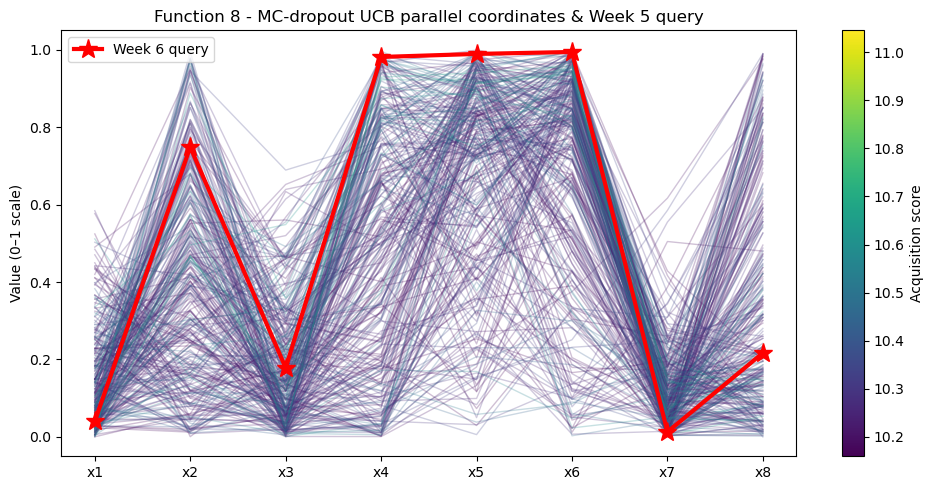

In [35]:
# Plot: parallel coordinates over the candidate pool scored by UCB (Function 8's MC-dropout
# acquisition) - the highest-dimensional function here, so parallel coordinates again.
plot_parallel_coordinates(
    pool, ucb_F8, query_F8,
    dim_labels=[f'x{i+1}' for i in range(8)],
    title='Function 8 - MC-dropout UCB parallel coordinates & Week 5 query'
)

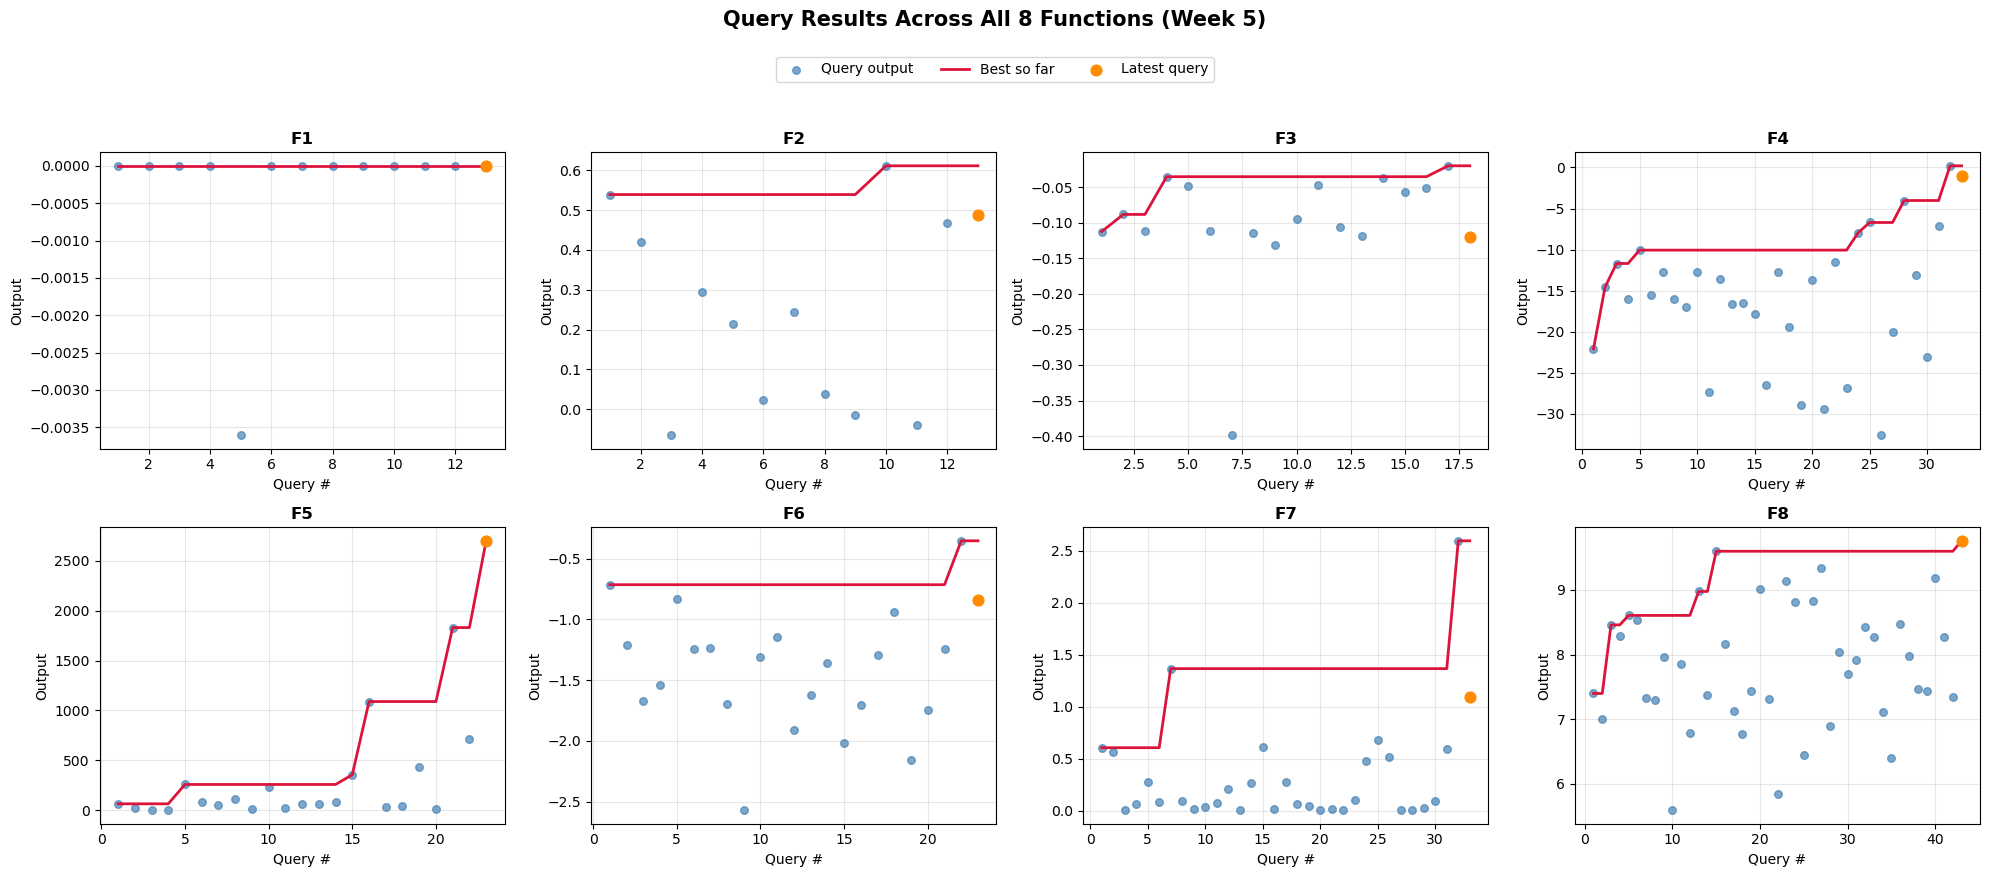

In [36]:
# =============================================================================
# Plot query results for all 8 functions
# =============================================================================
# For each function this shows every query's output (blue points) alongside
# the running best value found so far (red line) - a quick visual summary
# of how each search has progressed.

import matplotlib.pyplot as plt
import numpy as np

# Collect the outputs for each function.
# F3 was built with generic X / Y variable names instead of all_inputs_F3 / all_outputs_F3.
results = {
    "F1": all_outputs_F1,
    "F2": all_outputs_F2,
    "F3": Y,
    "F4": all_outputs_F4,
    "F5": all_outputs_F5,
    "F6": all_outputs_F6,
    "F7": all_outputs_F7,
    "F8": all_outputs_F8,
}

fig, axes = plt.subplots(2, 4, figsize=(20, 8))
axes = axes.ravel()

for ax, (name, y) in zip(axes, results.items()):
    y = np.asarray(y, dtype=float)
    x = np.arange(1, len(y) + 1)
    running_best = np.maximum.accumulate(y)

    ax.scatter(x, y, color="steelblue", alpha=0.7, s=30, label="Query output", zorder=2)
    ax.plot(x, running_best, color="crimson", linewidth=2, label="Best so far", zorder=3)
    ax.scatter([x[-1]], [y[-1]], color="darkorange", s=60, zorder=4, label="Latest query")

    ax.set_title(name, fontsize=12, fontweight="bold")
    ax.set_xlabel("Query #")
    ax.set_ylabel("Output")
    ax.grid(alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 1.04))
fig.suptitle("Query Results Across All 8 Functions (Week 5)", y=1.09, fontsize=15, fontweight="bold")

plt.tight_layout()
plt.show()
